<a href="https://colab.research.google.com/github/esinghbe23-ctrl/Multithreading/blob/main/Mini_Projects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#2.4)Run Multiple Threads and Wait for All to Complete
import threading
import time

def task(name, delay):
    print(f"{name} started")
    time.sleep(delay)
    print(f"{name} finished after {delay} seconds")
threads = []

for i in range(5):
    t = threading.Thread(target=task, args=(f"Thread-{i+1}", i+1))
    threads.append(t)

for t in threads:
    t.start()

for t in threads:
    t.join()

print("All threads completed")

Thread-1 started
Thread-2 started
Thread-3 started
Thread-4 started
Thread-5 started
Thread-1 finished after 1 seconds
Thread-2 finished after 2 seconds
Thread-3 finished after 3 seconds
Thread-4 finished after 4 seconds
Thread-5 finished after 5 seconds
All threads completed


In [ ]:
#2.5)Run Multiple Threads Equal to Number of CPU Cores
import threading
import multiprocessing
import time

num_cores = multiprocessing.cpu_count()
print("Number of CPU cores:", num_cores)

def worker(core_id):
    print(f"Thread for Core-{core_id} started")
    time.sleep(2)
    print(f"Thread for Core-{core_id} finished")

threads = []

for i in range(num_cores):
    t = threading.Thread(target=worker, args=(i+1,))
    threads.append(t)

for t in threads:
    t.start()

for t in threads:
    t.join()

print("All core threads completed")

Number of CPU cores: 2
Thread for Core-1 started
Thread for Core-2 started
Thread for Core-1 finishedThread for Core-2 finished

All core threads completed


In [ ]:
#Mini Project 1: Convert Multiple Files Using Threading

import threading

def read_file(filename):
    with open(filename, 'r') as f:
        data = f.read()
        print(f"\nContents of {filename}:\n{data}")

files = ['file1.txt', 'file2.txt', 'file3.txt']

threads = []

for file in files:
    t = threading.Thread(target=read_file, args=(file,))
    threads.append(t)
    t.start()

for t in threads:
    t.join()

print("All files processed")

In [ ]:
#Mini Project 2: Convert Multiple Files to Uppercase
import threading

def convert_uppercase(input_file, output_file):
    with open(input_file, 'r') as f:
        content = f.read()

    upper_content = content.upper()

    with open(output_file, 'w') as f:
        f.write(upper_content)

    print(f"Converted {input_file} -> {output_file}")

file_pairs = [
    ('file1.txt', 'upper1.txt'),
    ('file2.txt', 'upper2.txt'),
    ('file3.txt', 'upper3.txt')
]

threads = []

for input_file, output_file in file_pairs:
    t = threading.Thread(target=convert_uppercase, args=(input_file, output_file))
    threads.append(t)
    t.start()

for t in threads:
    t.join()

print("All files converted to uppercase")

In [ ]:
#Mini Project 3: Convert Multiple Images to Grey Scale
import zipfile
import os
import cv2
import threading

zip_file = 'file4.txt.zip'
extract_folder = 'images_folder'

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print('Images extracted successfully')
output_folder = 'gray_images'
os.makedirs(output_folder, exist_ok=True)
def convert_to_gray(image_name):
    input_path = os.path.join(extract_folder, image_name)
    output_path = os.path.join(output_folder, 'gray_' + image_name)

    img = cv2.imread(input_path)

    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        cv2.imwrite(output_path, gray)
        print(f'Converted {image_name}')
    else:
        print(f'Could not read {image_name}')
image_files = []

for file in os.listdir(extract_folder):
    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_files.append(file)

print('Images found:', image_files)
threads = []

for image_file in image_files:
    t = threading.Thread(target=convert_to_gray, args=(image_file,))
    threads.append(t)
    t.start()
for t in threads:
    t.join()

print('All images converted to grayscale')


Images extracted successfully
Images found: []
All images converted to grayscale


In [ ]:
#Mini Project 4: Convert Multiple Videos to Grey Scale
import zipfile
import os
import cv2
import threading

zip_file = 'file1.txt.zip'
extract_folder = 'videos_folder'

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print('Videos extracted successfully')
output_folder = 'gray_videos'
os.makedirs(output_folder, exist_ok=True)
def convert_video_to_gray(video_name):
    input_path = os.path.join(extract_folder, video_name)
    output_path = os.path.join(output_folder, 'gray_' + video_name)

    cap = cv2.VideoCapture(input_path)

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height), False)
    while True:
        ret, frame = cap.read()

        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        out.write(gray)

    cap.release()
    out.release()

    print(f'Converted {video_name}')
video_files = []

for file in os.listdir(extract_folder):
    if file.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
        video_files.append(file)

print('Videos found:', video_files)
threads = []

for video_file in video_files:
    t = threading.Thread(target=convert_video_to_gray, args=(video_file,))
    threads.append(t)
    t.start()
for t in threads:
    t.join()

print('All videos converted to grayscale')


Videos extracted successfully
Videos found: []
All videos converted to grayscale


Thread-1 started
Thread-2 started
Thread-3 started
Thread-4 started
Thread-5 started
Thread-1 finished
Thread-2 finished
Thread-3 finished
Thread-4 finished
Thread-5 finished
All threads completed
Total time: 5.005303144454956


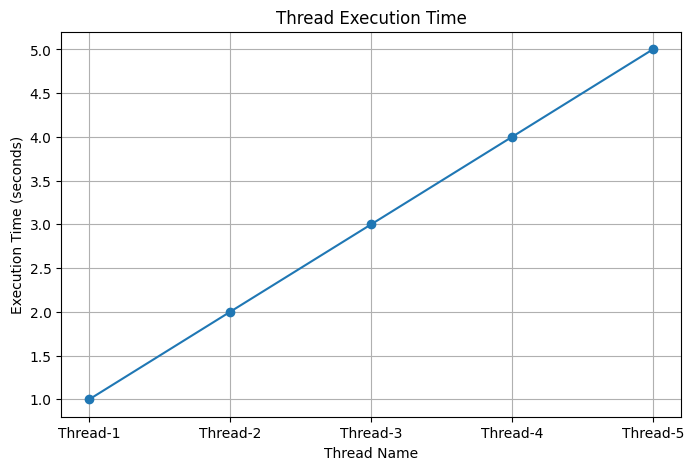

In [1]:
import threading
import time
import matplotlib.pyplot as plt

thread_names = []
thread_times = []

def task(name, delay):
    start = time.time()

    print(f"{name} started")
    time.sleep(delay)
    print(f"{name} finished")

    end = time.time()

    thread_names.append(name)
    thread_times.append(end - start)

threads = []
for i in range(5):
    t = threading.Thread(target=task, args=(f"Thread-{i+1}", i+1))
    threads.append(t)

start_total = time.time()

for t in threads:
    t.start()

for t in threads:
    t.join()

end_total = time.time()
print("All threads completed")
print("Total time:", end_total - start_total)

plt.figure(figsize=(8,5))
plt.plot(thread_names, thread_times, marker='o')
plt.xlabel('Thread Name')
plt.ylabel('Execution Time (seconds)')
plt.title('Thread Execution Time')
plt.grid(True)
plt.show()

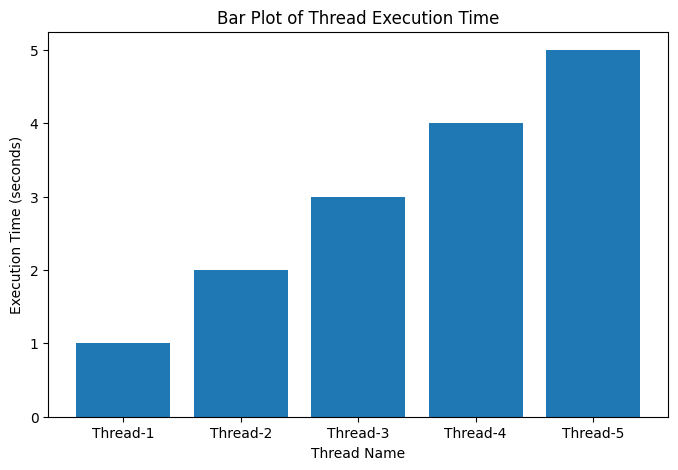

In [3]:
import matplotlib.pyplot as plt

thread_names = ['Thread-1', 'Thread-2', 'Thread-3', 'Thread-4', 'Thread-5']
thread_times = [1, 2, 3, 4, 5]

plt.figure(figsize=(8,5))
plt.bar(thread_names, thread_times)
plt.xlabel('Thread Name')
plt.ylabel('Execution Time (seconds)')
plt.title('Bar Plot of Thread Execution Time')
plt.show()